<a href="https://colab.research.google.com/github/nguyenduyvu61107/BTAINGUYENDUYVU2026/blob/main/BTAI_27042026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 6.5 MB/s eta 0:00:00


Giá cước ước tính (thang 100): 92.53
Điểm thưởng tài xế (thang 100): 90.97


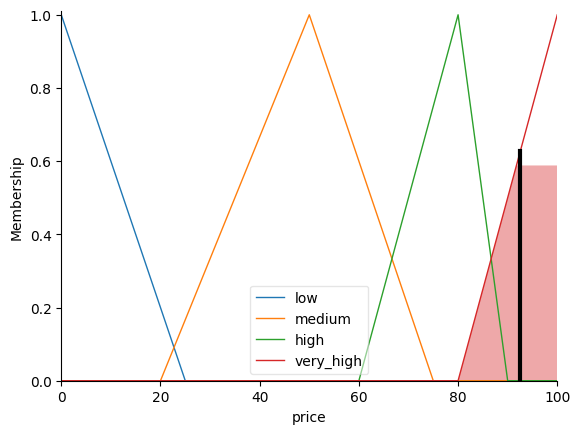

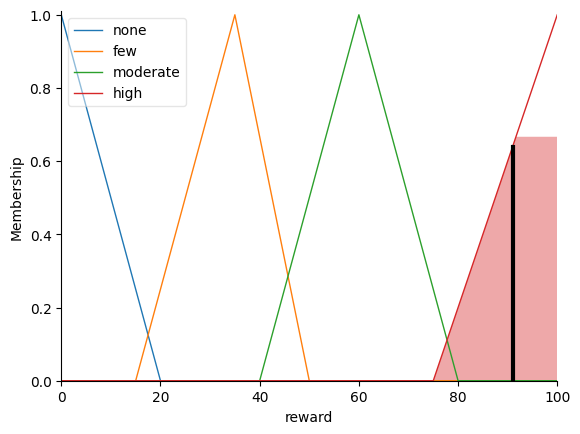

In [2]:
#2.11
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 6, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

price = ctrl.Consequent(np.arange(0, 101, 1), 'price')
reward = ctrl.Consequent(np.arange(0, 101, 1), 'reward')

distance['short'] = fuzzy.trapmf(distance.universe, [0, 0, 3, 5])
distance['medium'] = fuzzy.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzzy.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzzy.trapmf(distance.universe, [15, 32, 50, 50])

traffic['low'] = fuzzy.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzzy.trimf(traffic.universe, [20, 45, 70])
traffic['high'] = fuzzy.trimf(traffic.universe, [60, 100, 100])

demand['low'] = fuzzy.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzzy.trimf(demand.universe, [20, 45, 70])
demand['high'] = fuzzy.trimf(demand.universe, [60, 100, 100])

weather['good'] = fuzzy.trimf(weather.universe, [0, 0, 4])
weather['moderate'] = fuzzy.trimf(weather.universe, [3, 5, 7])
weather['bad'] = fuzzy.trimf(weather.universe, [6, 10, 10])

rating['poor'] = fuzzy.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzzy.trimf(rating.universe, [2, 3.25, 4.5])
rating['good'] = fuzzy.trimf(rating.universe, [3.5, 5, 5])

punctuality['late'] = fuzzy.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzzy.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzzy.trimf(punctuality.universe, [70, 100, 100])

price['low'] = fuzzy.trimf(price.universe, [0, 0, 25])
price['medium'] = fuzzy.trimf(price.universe, [20, 50, 75])
price['high'] = fuzzy.trimf(price.universe, [60, 80, 90])
price['very_high'] = fuzzy.trimf(price.universe, [80, 100, 100])

reward['none'] = fuzzy.trimf(reward.universe, [0, 0, 20])
reward['few'] = fuzzy.trimf(reward.universe, [15, 35, 50])
reward['moderate'] = fuzzy.trimf(reward.universe, [40, 60, 80])
reward['high'] = fuzzy.trimf(reward.universe, [75, 100, 100])

rules = [
    ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'] & weather['bad'], price['high']),
    ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & weather['moderate'], price['medium']),

    ctrl.Rule(rating['good'] & punctuality['early'], reward['high']),
    ctrl.Rule(rating['average'] & punctuality['on_time'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], reward['high']),
    ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], reward['moderate']),
    ctrl.Rule(rating['poor'] & punctuality['late'], reward['none']),
    ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], reward['high']),
    ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], reward['few']),
    ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], reward['few']),
    ctrl.Rule(distance['medium'] & weather['moderate'] & rating['good'], reward['moderate'])
]

grab_ctrl = ctrl.ControlSystem(rules)
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['distance'] = 25
grab_sim.input['traffic'] = 80
grab_sim.input['demand'] = 90
grab_sim.input['weather'] = 9
grab_sim.input['rating'] = 4.8
grab_sim.input['punctuality'] = 90

grab_sim.compute()

print(f"Giá cước ước tính (thang 100): {grab_sim.output['price']:.2f}")
print(f"Điểm thưởng tài xế (thang 100): {grab_sim.output['reward']:.2f}")

price.view(sim=grab_sim)
reward.view(sim=grab_sim)

Mức chiết khấu đề xuất: 58.33%


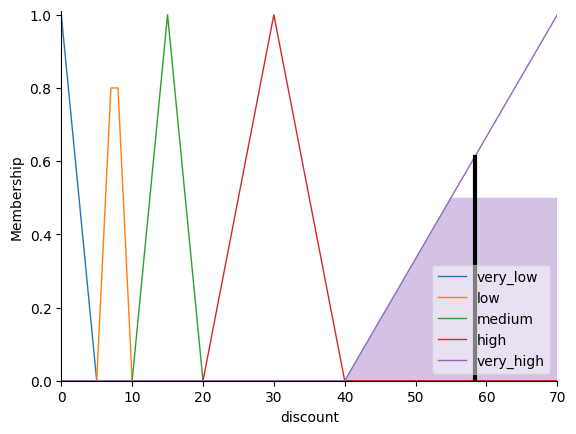

In [3]:
#2.12
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 1001, 1), 'sales')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
event = ctrl.Antecedent(np.arange(0, 11, 1), 'event')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

rating['low'] = fuzzy.trimf(rating.universe, [1, 1, 4.0])
rating['medium'] = fuzzy.trimf(rating.universe, [3.8, 4.25, 4.7])
rating['high'] = fuzzy.trimf(rating.universe, [4.5, 5.0, 5.0])

sales['low'] = fuzzy.trimf(sales.universe, [0, 0, 300])
sales['medium'] = fuzzy.trimf(sales.universe, [200, 500, 800])
sales['high'] = fuzzy.trimf(sales.universe, [700, 1000, 1000])

margin['low'] = fuzzy.trimf(margin.universe, [0, 0, 30])
margin['medium'] = fuzzy.trimf(margin.universe, [20, 50, 80])
margin['high'] = fuzzy.trimf(margin.universe, [70, 100, 100])

event['none'] = fuzzy.trimf(event.universe, [0, 0, 3])
event['moderate'] = fuzzy.trimf(event.universe, [2, 5, 8])
event['high'] = fuzzy.trimf(event.universe, [7, 10, 10])

competitor['low'] = fuzzy.trimf(competitor.universe, [0, 0, 20])
competitor['medium'] = fuzzy.trimf(competitor.universe, [15, 40, 65])
competitor['high'] = fuzzy.trimf(competitor.universe, [60, 100, 100])

discount['very_low'] = fuzzy.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzzy.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzzy.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzzy.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzzy.trimf(discount.universe, [40, 70, 70])

rules = [
    ctrl.Rule(rating['high'] & sales['high'] & margin['high'], discount['very_low']),
    ctrl.Rule(rating['low'] & sales['low'] & margin['high'], discount['high']),
    ctrl.Rule(event['high'] & competitor['high'], discount['very_high']),
    ctrl.Rule(rating['medium'] & sales['medium'] & margin['medium'], discount['medium']),
    ctrl.Rule(competitor['low'] & margin['low'] & sales['high'], discount['very_low']),
    ctrl.Rule(rating['low'] & event['none'], discount['medium']),
    ctrl.Rule(sales['low'] & margin['low'], discount['very_high'])
]

shopee_ctrl = ctrl.ControlSystem(rules)
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)

shopee_sim.input['rating'] = 4.3
shopee_sim.input['sales'] = 500
shopee_sim.input['margin'] = 15
shopee_sim.input['event'] = 9
shopee_sim.input['competitor'] = 80

shopee_sim.compute()
print(f"Mức chiết khấu đề xuất: {shopee_sim.output['discount']:.2f}%")
discount.view(sim=shopee_sim)

Mức chiết khấu: 17.50%


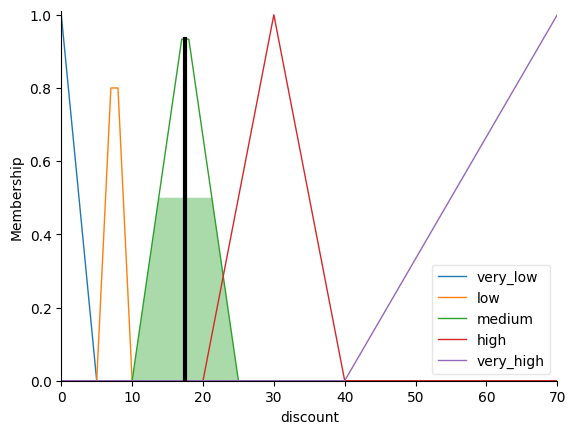

In [5]:
#2.13
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'pressure')
reputation = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'reputation')
margin = ctrl.Antecedent(np.arange(0, 101, 1), 'margin')
seasonal = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

demand['low'] = fuzzy.trimf(demand.universe, [0, 0, 40])
demand['medium'] = fuzzy.trimf(demand.universe, [30, 50, 70])
demand['high'] = fuzzy.trimf(demand.universe, [60, 100, 100])

pressure['low'] = fuzzy.trimf(pressure.universe, [0, 0, 40])
pressure['medium'] = fuzzy.trimf(pressure.universe, [30, 50, 70])
pressure['high'] = fuzzy.trimf(pressure.universe, [60, 100, 100])

reputation['low'] = fuzzy.trimf(reputation.universe, [1, 1, 4.0])
reputation['medium'] = fuzzy.trimf(reputation.universe, [3.8, 4.25, 4.7])
reputation['high'] = fuzzy.trimf(reputation.universe, [4.5, 5.0, 5.0])

margin['low'] = fuzzy.trimf(margin.universe, [0, 0, 30])
margin['medium'] = fuzzy.trimf(margin.universe, [20, 50, 80])
margin['high'] = fuzzy.trimf(margin.universe, [70, 100, 100])

seasonal['none'] = fuzzy.trimf(seasonal.universe, [0, 0, 3])
seasonal['moderate'] = fuzzy.trimf(seasonal.universe, [2, 5, 8])
seasonal['high'] = fuzzy.trimf(seasonal.universe, [7, 10, 10])

discount['very_low'] = fuzzy.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzzy.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzzy.trimf(discount.universe, [10, 17.5, 25])
discount['high'] = fuzzy.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzzy.trimf(discount.universe, [40, 70, 70])

rules = [
    ctrl.Rule(demand['high'] & pressure['low'] & margin['low'], discount['very_low']),
    ctrl.Rule(demand['low'] & pressure['high'] & margin['high'], discount['high']),
    ctrl.Rule(reputation['high'] & margin['medium'] & seasonal['high'], discount['medium']),
    ctrl.Rule(pressure['high'] & seasonal['high'] & margin['high'], discount['very_high']),
    ctrl.Rule(reputation['low'] & demand['medium'] & margin['low'], discount['medium']),
    ctrl.Rule(demand['high'] & seasonal['none'] & pressure['low'], discount['very_low']),
    ctrl.Rule(margin['high'] & pressure['medium'] & seasonal['moderate'], discount['medium'])
]

special_item_ctrl = ctrl.ControlSystem(rules)
special_sim = ctrl.ControlSystemSimulation(special_item_ctrl)

special_sim.input['demand'] = 90
special_sim.input['pressure'] = 50
special_sim.input['reputation'] = 4.2
special_sim.input['margin'] = 85
special_sim.input['seasonal'] = 5

special_sim.compute()

print(f"Mức chiết khấu: {special_sim.output['discount']:.2f}%")

discount.view(sim=special_sim)

Số lượng đơn hàng nên kết hợp: 8.4 đơn
Mức độ ưu tiên giao hàng: 50.00%


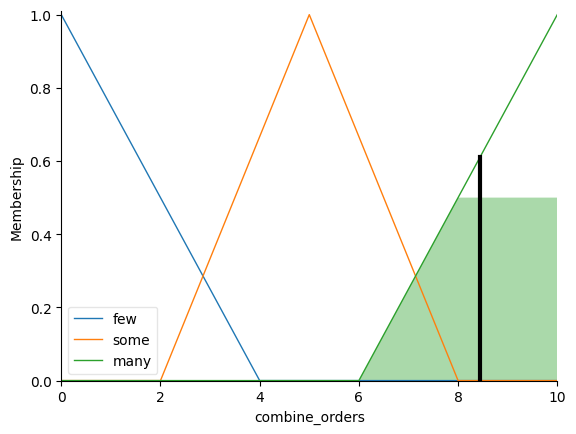

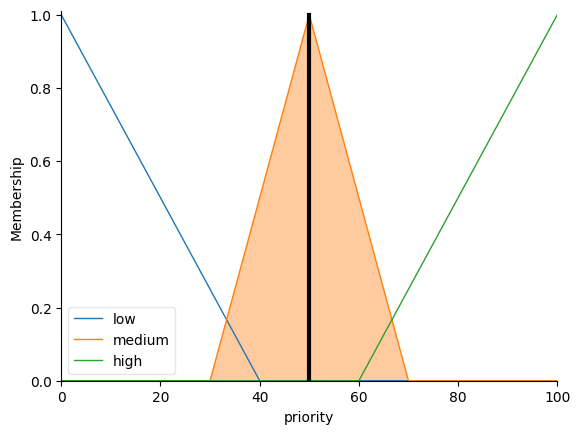

In [11]:
#2.14
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

density = ctrl.Antecedent(np.arange(0, 101, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')

combine_orders = ctrl.Consequent(np.arange(0, 11, 1), 'combine_orders')
priority = ctrl.Consequent(np.arange(0, 101, 1), 'priority')

density['low'] = fuzzy.trimf(density.universe, [0, 0, 40])
density['medium'] = fuzzy.trimf(density.universe, [30, 50, 70])
density['high'] = fuzzy.trimf(density.universe, [60, 100, 100])

urgency['low'] = fuzzy.trimf(urgency.universe, [0, 0, 40])
urgency['medium'] = fuzzy.trimf(urgency.universe, [30, 50, 70])
urgency['high'] = fuzzy.trimf(urgency.universe, [60, 100, 100])

driver_load['low'] = fuzzy.trimf(driver_load.universe, [0, 0, 40])
driver_load['medium'] = fuzzy.trimf(driver_load.universe, [30, 50, 70])
driver_load['high'] = fuzzy.trimf(driver_load.universe, [60, 100, 100])

traffic['low'] = fuzzy.trimf(traffic.universe, [0, 0, 40])
traffic['medium'] = fuzzy.trimf(traffic.universe, [30, 50, 70])
traffic['high'] = fuzzy.trimf(traffic.universe, [60, 100, 100])

profit['low'] = fuzzy.trimf(profit.universe, [0, 0, 40])
profit['medium'] = fuzzy.trimf(profit.universe, [30, 50, 70])
profit['high'] = fuzzy.trimf(profit.universe, [60, 100, 100])

combine_orders['few'] = fuzzy.trimf(combine_orders.universe, [0, 0, 4])
combine_orders['some'] = fuzzy.trimf(combine_orders.universe, [2, 5, 8])
combine_orders['many'] = fuzzy.trimf(combine_orders.universe, [6, 10, 10])

priority['low'] = fuzzy.trimf(priority.universe, [0, 0, 40])
priority['medium'] = fuzzy.trimf(priority.universe, [30, 50, 70])
priority['high'] = fuzzy.trimf(priority.universe, [60, 100, 100])

rules = [

    ctrl.Rule(density['high'] & driver_load['low'] & traffic['low'], combine_orders['many']),
    ctrl.Rule(density['medium'] & traffic['high'] & urgency['medium'], combine_orders['some']),
    ctrl.Rule(driver_load['high'] & density['high'] & profit['medium'], combine_orders['some']),
    ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine_orders['some']),
    ctrl.Rule(profit['high'] & urgency['high'] & traffic['high'], combine_orders['some']),

    ctrl.Rule(density['high'] & urgency['medium'] & driver_load['low'], combine_orders['many']),
    ctrl.Rule(density['low'] & urgency['low'], combine_orders['few']),
    ctrl.Rule(density['medium'], combine_orders['some']),

    ctrl.Rule(urgency['high'] & profit['high'], priority['high']),
    ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium']),
    ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low']),
    ctrl.Rule(urgency['medium'], priority['medium'])
]
logistics_ctrl = ctrl.ControlSystem(rules)
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)
logistics_sim.input['density'] = 90
logistics_sim.input['urgency'] = 50
logistics_sim.input['driver_load'] = 20
logistics_sim.input['traffic'] = 50
logistics_sim.input['profit'] = 50
logistics_sim.compute()

print(f"Số lượng đơn hàng nên kết hợp: {logistics_sim.output['combine_orders']:.1f} đơn")
print(f"Mức độ ưu tiên giao hàng: {logistics_sim.output['priority']:.2f}%")
combine_orders.view(sim=logistics_sim)
priority.view(sim=logistics_sim)